In [39]:
import numpy as np
import cv2

import PIL.Image as Image
import os
import matplotlib.pyplot as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow_hub.keras_layer import KerasLayer

In [40]:

from tensorflow_hub.keras_layer import KerasLayer

model_url = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4"

classifier = tf.keras.Sequential([
    KerasLayer(model_url, input_shape=(224, 224, 3), trainable=False)
])



In [ ]:
print("TensorFlow version:", tf.__version__)
print("TensorFlow Hub version:", hub.__version__)

TensorFlow version: 2.17.1
TensorFlow Hub version: 0.16.1


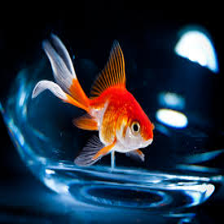

In [ ]:
gold_fish=Image.open('goldfish.jpeg').resize((224,224))
gold_fish

In [ ]:
gold_fish=np.array(gold_fish)/255.0
gold_fish.shape

(224, 224, 3)

In [ ]:
gold_fish[np.newaxis,...].shape

(1, 224, 224, 3)

In [ ]:
result=classifier.predict(gold_fish[np.newaxis,...])

1/1 [==============================] - 1s 1s/step


In [ ]:
result

array([[ 0.29608104,  3.950069  , 10.842676  , ..., -1.8849486 ,
        -0.21468438,  0.39133137]], dtype=float32)

In [ ]:
predicted_label_index=np.argmax(result)
predicted_label_index

2

In [ ]:
with open("imagenet-labels.txt", "r") as f:
    image_labels = f.read().splitlines()  # Use splitlines() to split by newlines

print(image_labels[:5])  # Print the first 5 labels to verify

['one was mimssing', 'tench', 'goldfish', 'great white shark', 'tiger shark']


In [ ]:
image_labels[predicted_label_index]

'goldfish'

In [52]:
dataset_url = 'http://www.robots.ox.ac.uk/~vgg/data/flowers/102/102flowers.tgz'
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url, cache_dir='.',untar=True)

In [53]:
data_dir

'./datasets/flower_photos'

In [54]:
import pathlib
data_dir=pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [55]:

list(data_dir.glob('*/*.jpg'))[:5]

[]

In [56]:
image_count=len(list(data_dir.glob('*/*.jpg')))
image_count

0

In [ ]:
roses=list(data_dir.glob('roses/*'))
roses[:5]

[]

In [ ]:
Image.open(str(roses[2]))

Here ,in google collab i want to convert the dataset for window but it is converted into posixpath .So,while doing in jupyter notebook use str() because it gives the precise one.


In [ ]:
tulips=list(data_dir.glob('tulips/*'))[:5]

In [ ]:
Image.open(str(tulips[0]))

In [ ]:
flowers_image_dict={
    'roses':list(data_dir.glob('roses/*')),
    'tulips':list(data_dir.glob('tulips/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'daisy':list(data_dir.glob('daisy/*'))
}


In [ ]:
flowers_labels_dict={
    'roses':0,
    'tulips':1,
    'dandelion':2,
    'sunflowers':3,
    'daisy':4
}

In [ ]:
img=cv2.imread(str(flowers_image_dict['roses'][0]))
img.shape

In [ ]:
str(flowers_image_dict['roses'][0])

In [ ]:
cv2.resize(img,(224,224))

In [ ]:
X,y=[],[]
for flowers_name,images in flowers_image_dict.items():
  for image in images:
    img=cv2.imread(str(image))
    img_resized=cv2.resize(img,(224,224))
    X.append(img_resized)
    y.append(flowers_labels_dict[flowers_name])


In [ ]:
X=np.array(X)
y=np.array(y)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [ ]:
X_trainscaled=X_train/255
X_testscaled=X_test/255

In [ ]:
plt.imshow(X[0])

In [ ]:
plt.imshow(X[50])

In [ ]:
predicted=classifier.predict(np.array([X[0],X[1],X[2]]))
predicted=np.argmax(predicted,axis=1)
predicted

Feature selection model

In [ ]:
feature_extractor_model='https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4'
pretrained_model_without_top_layer=hub.KerasLayer(feature_extractor_model,input_shape=(224,224,3),trainable=False)


In [ ]:

model=Sequential()
model.add(pretrained_model_without_top_layer)
model.add(Dense(5))
model.summary()
#activation=softmax
#I am using feature extraction .So, I dont need to provide activation .
#If ,I was about to do  fine tunning or classification then I must provide activation.

In [ ]:
model.compile(optimizer='adam',loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),metrics=['acc'])


In [ ]:
model.fit(X_trainscaled, y_train, batch_size=32, epochs=5)

Due to some problem in html link of the flower i.e. it is not working,but the code implimentation is fine and I have gained some knowledge